# Thesis-ready result plots

This notebook creates clean result figures for the thesis comparison of snow depth from FSM2, seNorge and SNOWPACK in Jotunheimen.

Figures are saved as both high-resolution PNG and PDF in `figures_thesis/`.

No seaborn is used.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
import xarray as xr

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED = DATA_DIR / "processed"
FIG_DIR = PROJECT_ROOT / "figures_thesis"
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

MODEL_COLORS = {
    "FSM2": "#4c78a8",
    "seNorge": "#f58518",
    "SNOWPACK": "#54a24b",
}
MODEL_MARKERS = {
    "FSM2": "o",
    "seNorge": "s",
    "SNOWPACK": "^",
}


def save_figure(fig, name):
    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved: {pdf_path.relative_to(PROJECT_ROOT)}")

PROJECT_ROOT, FIG_DIR

(PosixPath('/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models'),
 PosixPath('/Users/malki/Documents/Skole/Masteroppgave/Master_snow_models/figures_thesis'))

## Load data and harmonise column names

In [2]:
obs_val = pd.read_csv(PROCESSED / "observation_validation_three_models.csv")
obs_ts = pd.read_csv(PROCESSED / "observation_validation_timeseries.csv", parse_dates=["time"])
sp_ref = pd.read_csv(PROCESSED / "model_comparison_metrics.csv")
seasonal = pd.read_csv(PROCESSED / "seasonal_model_metrics.csv")

# Add elevation to observation validation if it is not already present.
# The observation-validation output contains the nearest SNOWPACK virtual station;
# that station elevation is used as an approximate elevation for elevation plots.
if "elevation" not in obs_val.columns:
    snowpack_meta = xr.open_dataset(PROCESSED / "snowpack_all.nc")[["HS_mod"]]
    elev_lookup = pd.Series(
        snowpack_meta["elev"].values,
        index=snowpack_meta["station"].values,
    )
    obs_val["elevation"] = obs_val["SNOWPACK_Station"].map(elev_lookup)

# Standardised model/metric column maps for the observation validation table.
obs_metric_cols = {
    "FSM2": {"rmse": "FSM2_RMSE", "bias": "FSM2_Bias", "corr": "FSM2_Corr"},
    "seNorge": {"rmse": "seNorge_RMSE", "bias": "seNorge_Bias", "corr": "seNorge_Corr"},
    "SNOWPACK": {"rmse": "SNOWPACK_RMSE", "bias": "SNOWPACK_Bias", "corr": "SNOWPACK_Corr"},
}

sp_ref_metric_cols = {
    "FSM2": {"rmse": "rmse_fsm", "bias": "bias_fsm", "corr": "corr_fsm"},
    "seNorge": {"rmse": "rmse_senorge", "bias": "bias_senorge", "corr": "corr_senorge"},
}

print("Observation validation:", obs_val.shape)
print("Observation time series:", obs_ts.shape)
print("SNOWPACK-reference metrics:", sp_ref.shape)
print("Seasonal metrics:", seasonal.shape)
obs_val.head()

Observation validation: (11, 30)
Observation time series: (2742, 6)
SNOWPACK-reference metrics: (4484, 10)
Seasonal metrics: (17936, 18)


,Station,Station_Code,lat,lon,x_utm33,y_utm33,Period_Start,Period_End,FSM2_x,FSM2_y,...,seNorge_Corr,seNorge_N,SNOWPACK_Bias,SNOWPACK_RMSE,SNOWPACK_Corr,SNOWPACK_N,N_Days,best_model_rmse,worst_model_rmse,elevation
0,Øvre Heimdalsvatn,SN13750,60.9536,8.3536,140427.405303,6.775882e+06,2024-09-01,2025-05-31,140000.0,6776000.0,...,0.837661,249,0.578887,0.742371,0.670797,249,249,FSM2,SNOWPACK,1313.0
1,Fv51 Valdresflye,SN13760,61.1331,8.8225,167628.467116,6.793327e+06,2024-09-01,2025-05-31,168000.0,6793000.0,...,0.464696,213,-0.407968,0.601916,0.457993,213,213,FSM2,SNOWPACK,854.0
2,Juvvasshøe,SN15270,61.8903,7.1922,90287.517125,6.886638e+06,2024-10-18,2025-05-31,90000.0,6887000.0,...,-0.241051,226,2.293094,2.490752,0.934284,226,226,FSM2,SNOWPACK,1427.0
3,Bøverdal,SN15430,61.0975,8.0681,126719.174335,6.793451e+06,2024-09-01,2025-05-31,127000.0,6793000.0,...,0.427582,266,0.613823,0.790029,0.199029,266,266,seNorge,FSM2,1501.0
4,Skjåk,SN15660,61.0753,8.0275,124274.980706,6.791221e+06,2024-09-01,2025-05-31,124000.0,6791000.0,...,0.201566,268,0.624855,0.804264,0.123952,268,268,seNorge,FSM2,1501.0


## 1. Modelled versus observed snow depth

Saved: figures_thesis/01_modelled_vs_observed_scatter.png
Saved: figures_thesis/01_modelled_vs_observed_scatter.pdf


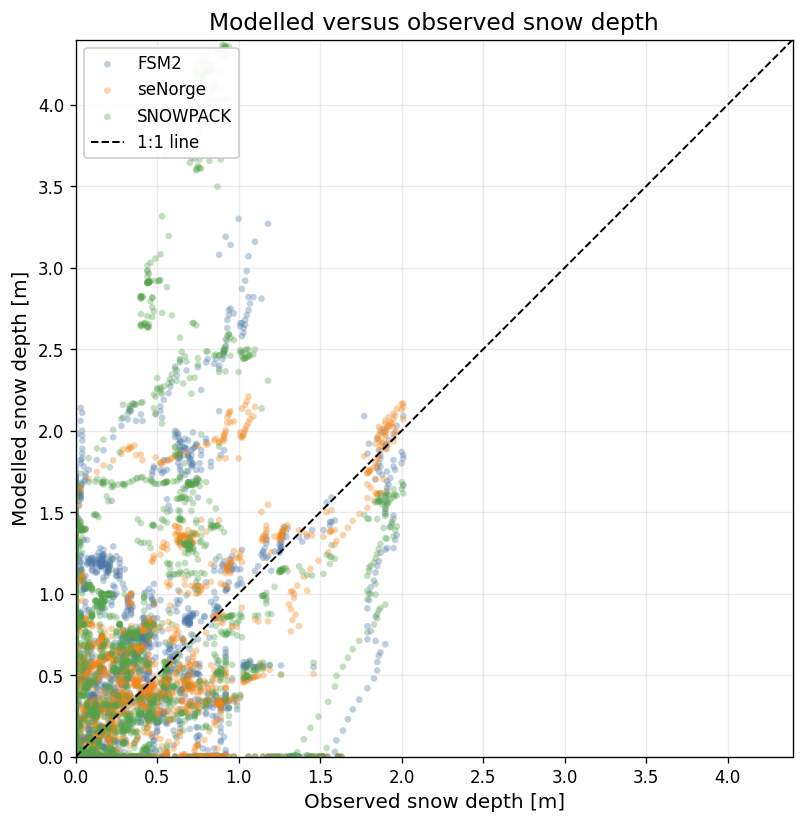

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 7.0))

max_value = np.nanmax(obs_ts[["OBS", "FSM2", "seNorge", "SNOWPACK"]].to_numpy())
axis_max = np.ceil(max_value * 10) / 10

for model in ["FSM2", "seNorge", "SNOWPACK"]:
    ax.scatter(
        obs_ts["OBS"],
        obs_ts[model],
        s=16,
        alpha=0.35,
        color=MODEL_COLORS[model],
        label=model,
        edgecolor="none",
    )

ax.plot([0, axis_max], [0, axis_max], color="black", linestyle="--", linewidth=1.2, label="1:1 line")
ax.set_xlim(0, axis_max)
ax.set_ylim(0, axis_max)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Observed snow depth [m]")
ax.set_ylabel("Modelled snow depth [m]")
ax.set_title("Modelled versus observed snow depth")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", framealpha=0.95)
fig.tight_layout()
save_figure(fig, "01_modelled_vs_observed_scatter")
plt.show()

## 2. Mean RMSE, bias and correlation against observations

Saved: figures_thesis/02_mean_rmse_observations.png
Saved: figures_thesis/02_mean_rmse_observations.pdf


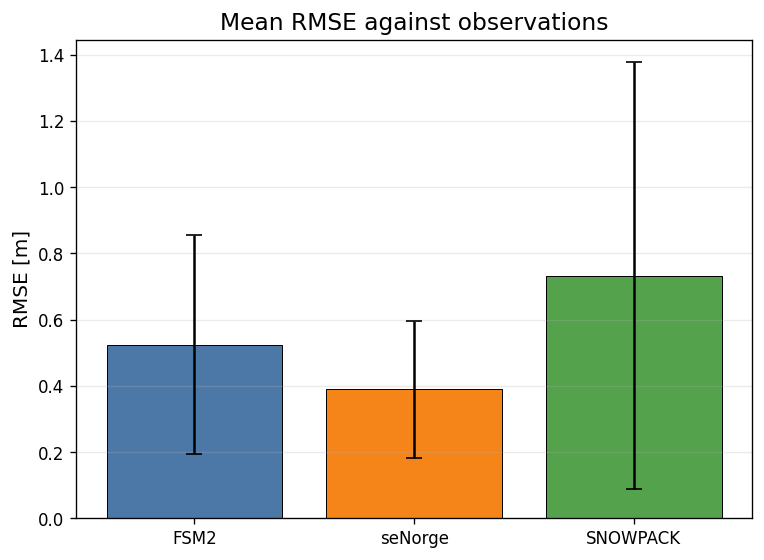

Saved: figures_thesis/03_mean_bias_observations.png
Saved: figures_thesis/03_mean_bias_observations.pdf


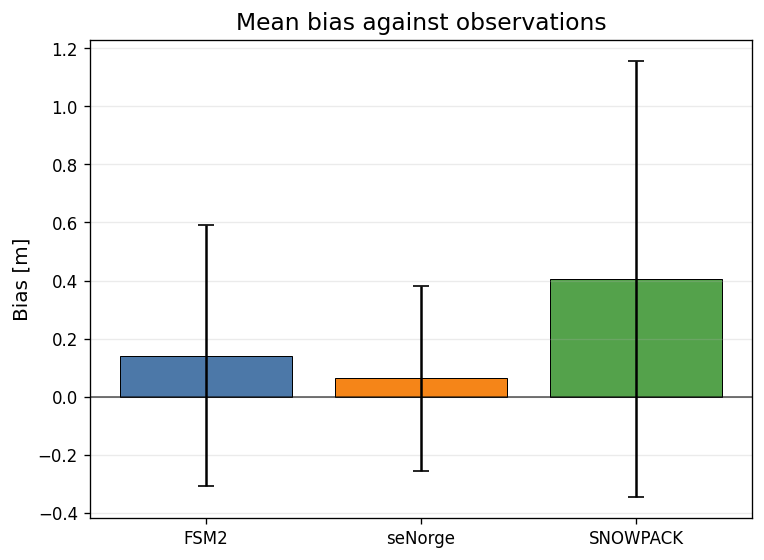

Saved: figures_thesis/04_mean_correlation_observations.png
Saved: figures_thesis/04_mean_correlation_observations.pdf


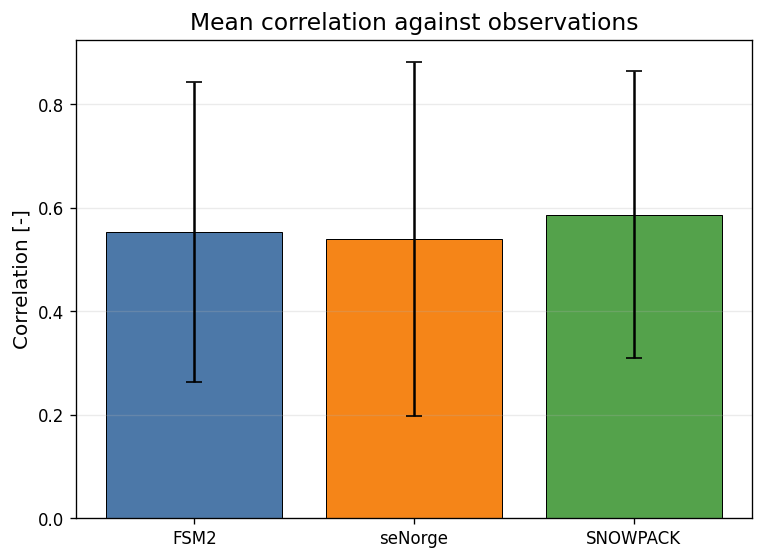

,model,rmse_mean,rmse_std,bias_mean,bias_std,corr_mean,corr_std
0,FSM2,0.524,0.331,0.141,0.450,0.552,0.290
1,seNorge,0.390,0.207,0.064,0.319,0.540,0.341
2,SNOWPACK,0.733,0.644,0.405,0.749,0.586,0.277


In [4]:
metric_settings = {
    "rmse": ("Mean RMSE against observations", "RMSE [m]", "02_mean_rmse_observations"),
    "bias": ("Mean bias against observations", "Bias [m]", "03_mean_bias_observations"),
    "corr": ("Mean correlation against observations", "Correlation [-]", "04_mean_correlation_observations"),
}

summary_records = []
for model in ["FSM2", "seNorge", "SNOWPACK"]:
    record = {"model": model}
    for metric in ["rmse", "bias", "corr"]:
        values = obs_val[obs_metric_cols[model][metric]]
        record[f"{metric}_mean"] = values.mean()
        record[f"{metric}_std"] = values.std()
    summary_records.append(record)
obs_summary = pd.DataFrame(summary_records)

for metric, (title, ylabel, filename) in metric_settings.items():
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    models = ["FSM2", "seNorge", "SNOWPACK"]
    means = [obs_summary.loc[obs_summary["model"] == m, f"{metric}_mean"].iloc[0] for m in models]
    stds = [obs_summary.loc[obs_summary["model"] == m, f"{metric}_std"].iloc[0] for m in models]
    colors = [MODEL_COLORS[m] for m in models]

    ax.bar(models, means, yerr=stds, color=colors, capsize=5, edgecolor="black", linewidth=0.6)
    if metric == "bias":
        ax.axhline(0, color="black", linewidth=0.9, alpha=0.7)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()

obs_summary.round(3)

## 3. RMSE versus elevation

Saved: figures_thesis/05_rmse_versus_elevation.png
Saved: figures_thesis/05_rmse_versus_elevation.pdf


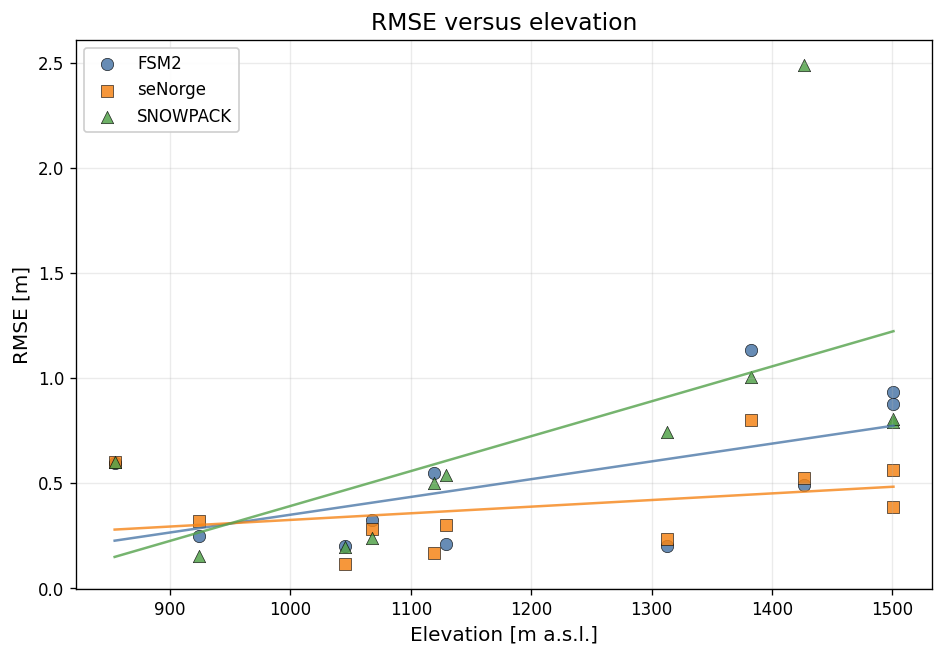

In [5]:
fig, ax = plt.subplots(figsize=(8.0, 5.6))

x = obs_val["elevation"].astype(float)
for model in ["FSM2", "seNorge", "SNOWPACK"]:
    y = obs_val[obs_metric_cols[model]["rmse"]].astype(float)
    ax.scatter(
        x,
        y,
        s=55,
        color=MODEL_COLORS[model],
        marker=MODEL_MARKERS[model],
        label=model,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4,
    )
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() >= 2:
        coeff = np.polyfit(x[valid], y[valid], 1)
        x_line = np.linspace(x[valid].min(), x[valid].max(), 100)
        y_line = coeff[0] * x_line + coeff[1]
        ax.plot(x_line, y_line, color=MODEL_COLORS[model], linewidth=1.5, alpha=0.8)

ax.set_xlabel("Elevation [m a.s.l.]")
ax.set_ylabel("RMSE [m]")
ax.set_title("RMSE versus elevation")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", framealpha=0.95)
fig.tight_layout()
save_figure(fig, "05_rmse_versus_elevation")
plt.show()

## 4. Bias versus elevation

Saved: figures_thesis/06_bias_versus_elevation.png
Saved: figures_thesis/06_bias_versus_elevation.pdf


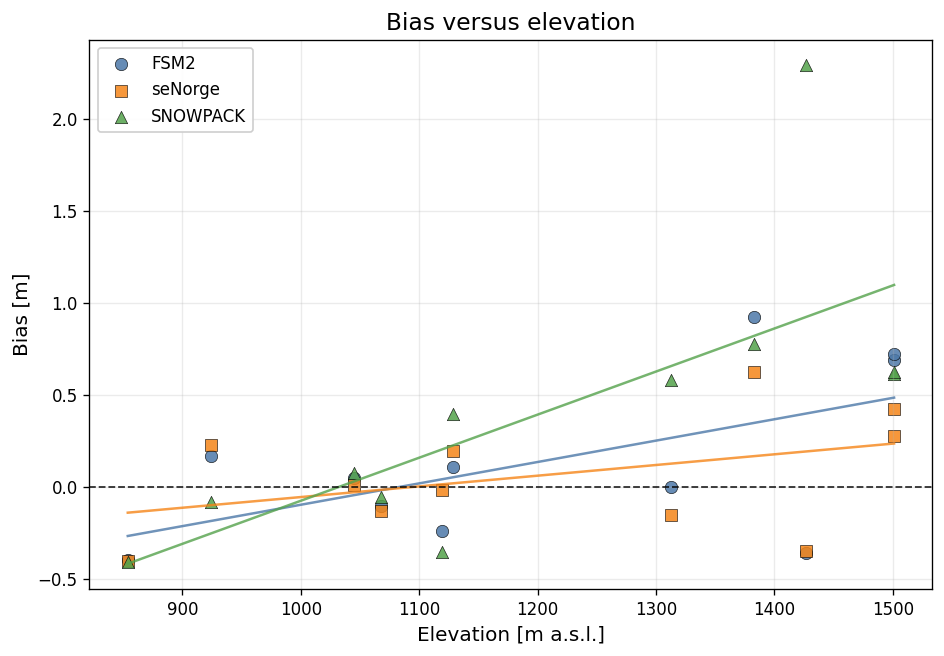

In [6]:
fig, ax = plt.subplots(figsize=(8.0, 5.6))

x = obs_val["elevation"].astype(float)
for model in ["FSM2", "seNorge", "SNOWPACK"]:
    y = obs_val[obs_metric_cols[model]["bias"]].astype(float)
    ax.scatter(
        x,
        y,
        s=55,
        color=MODEL_COLORS[model],
        marker=MODEL_MARKERS[model],
        label=model,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.4,
    )
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() >= 2:
        coeff = np.polyfit(x[valid], y[valid], 1)
        x_line = np.linspace(x[valid].min(), x[valid].max(), 100)
        y_line = coeff[0] * x_line + coeff[1]
        ax.plot(x_line, y_line, color=MODEL_COLORS[model], linewidth=1.5, alpha=0.8)

ax.axhline(0, color="black", linestyle="--", linewidth=1.1, alpha=0.8)
ax.set_xlabel("Elevation [m a.s.l.]")
ax.set_ylabel("Bias [m]")
ax.set_title("Bias versus elevation")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", framealpha=0.95)
fig.tight_layout()
save_figure(fig, "06_bias_versus_elevation")
plt.show()

## 5. Seasonal RMSE comparison

Saved: figures_thesis/07_seasonal_rmse_comparison.png
Saved: figures_thesis/07_seasonal_rmse_comparison.pdf


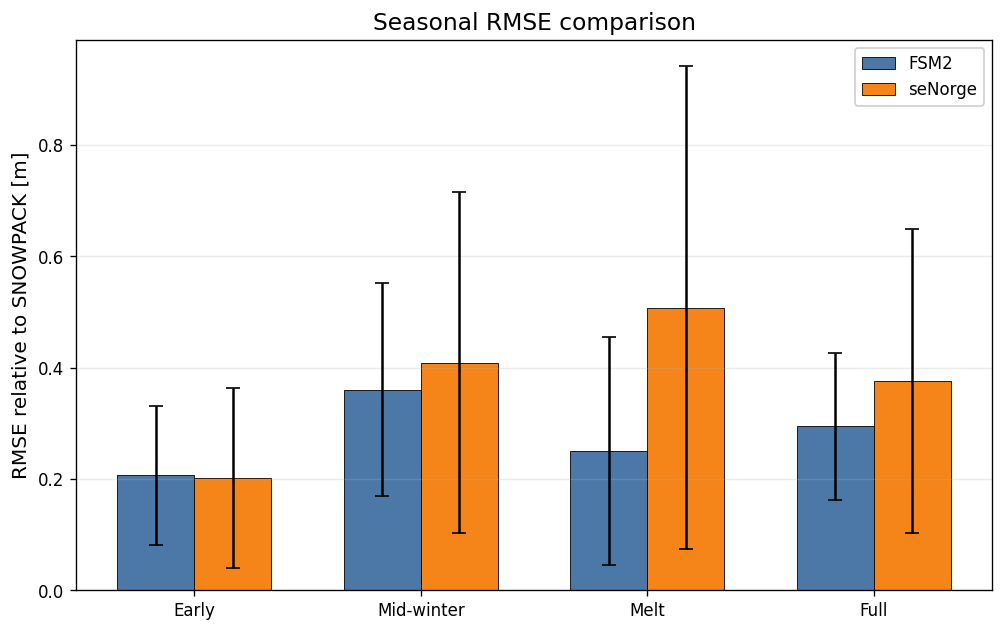

In [7]:
season_order = ["Early season", "Mid-winter", "Melt season", "Full season"]
season_labels_short = ["Early", "Mid-winter", "Melt", "Full"]
models = ["FSM2", "seNorge"]

fig, ax = plt.subplots(figsize=(8.5, 5.4))
x = np.arange(len(season_order))
width = 0.34

for offset, model in zip([-width / 2, width / 2], models):
    col = "rmse_fsm" if model == "FSM2" else "rmse_senorge"
    means = [seasonal.loc[seasonal["season_label"] == season, col].mean() for season in season_order]
    stds = [seasonal.loc[seasonal["season_label"] == season, col].std() for season in season_order]
    ax.bar(
        x + offset,
        means,
        width,
        yerr=stds,
        capsize=4,
        color=MODEL_COLORS[model],
        edgecolor="black",
        linewidth=0.5,
        label=model,
    )

ax.set_xticks(x)
ax.set_xticklabels(season_labels_short)
ax.set_ylabel("RMSE relative to SNOWPACK [m]")
ax.set_title("Seasonal RMSE comparison")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(framealpha=0.95)
fig.tight_layout()
save_figure(fig, "07_seasonal_rmse_comparison")
plt.show()

## 6. Difference map: FSM2 minus seNorge snow depth

The map uses seasonal mean snow depth over the SNOWPACK virtual-station extent, with a margin around Jotunheimen.

Saved: figures_thesis/08_difference_map_midwinter_mean.png
Saved: figures_thesis/08_difference_map_midwinter_mean.pdf


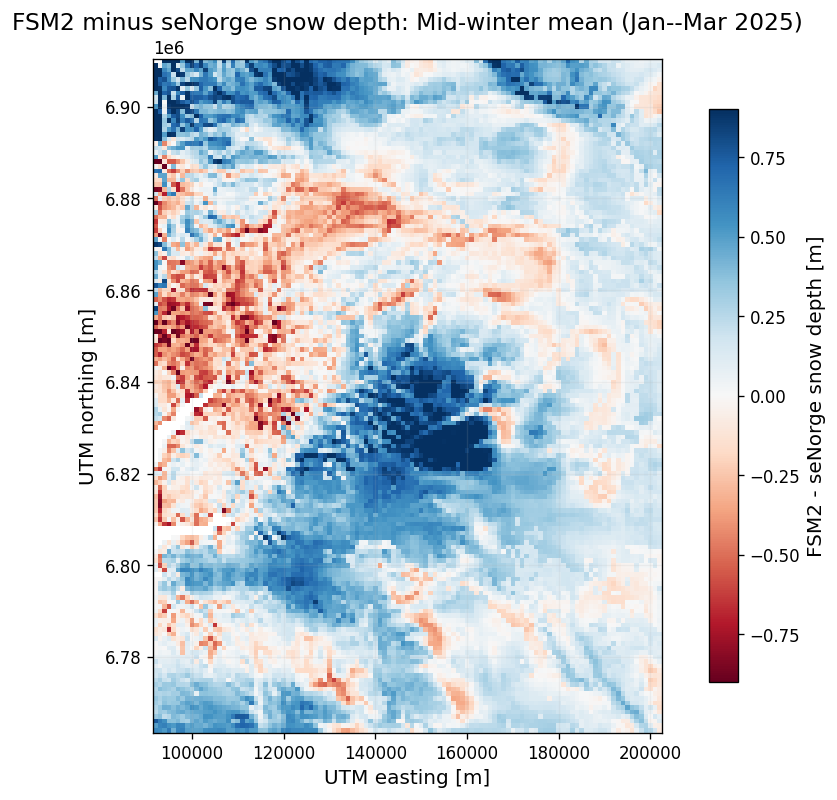

Saved: figures_thesis/09_difference_map_melt_mean.png
Saved: figures_thesis/09_difference_map_melt_mean.pdf


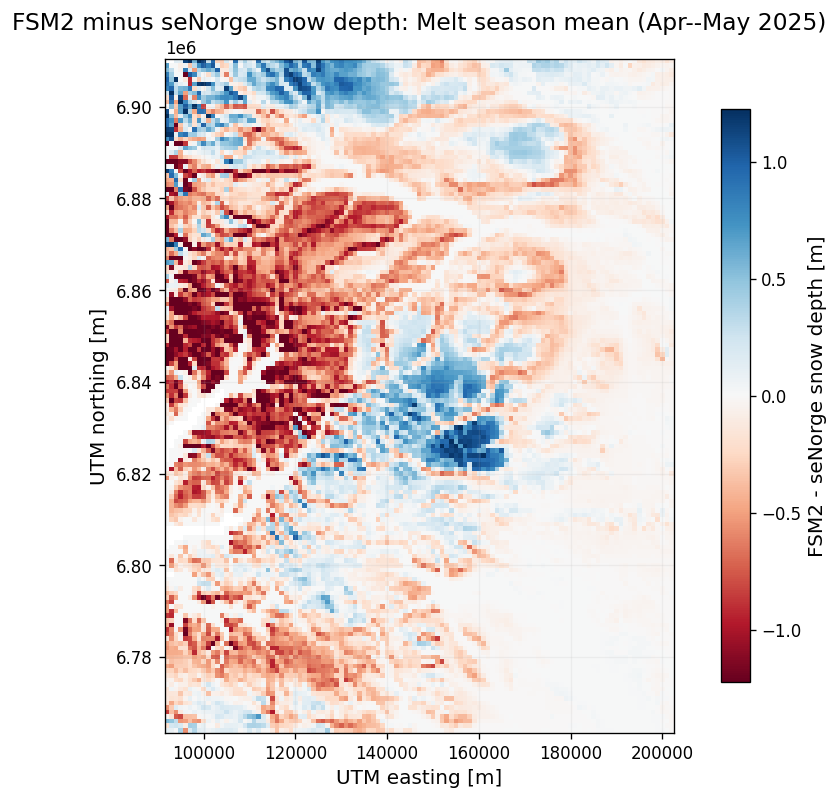

In [8]:
def subset_to_snowpack_extent(da, snowpack_ds, margin=10000):
    x_min = float(snowpack_ds["x"].min()) - margin
    x_max = float(snowpack_ds["x"].max()) + margin
    y_min = float(snowpack_ds["y"].min()) - margin
    y_max = float(snowpack_ds["y"].max()) + margin
    return da.sel(x=slice(x_min, x_max), y=slice(y_min, y_max))

snowpack_ds = xr.open_dataset(PROCESSED / "snowpack_all.nc")
fsm_ds = xr.open_dataset(PROCESSED / "fsm2_sd_all.nc")
senorge_ds = xr.open_dataset(PROCESSED / "senorge_all.nc")

fsm_sd = fsm_ds["snow_depth"] / 1000.0
senorge_sd = senorge_ds["snow_depth"] / 100.0
fsm_sub = subset_to_snowpack_extent(fsm_sd, snowpack_ds)
senorge_sub = subset_to_snowpack_extent(senorge_sd, snowpack_ds)

map_periods = {
    "Mid-winter mean (Jan--Mar 2025)": ("2025-01-01", "2025-03-31", "08_difference_map_midwinter_mean"),
    "Melt season mean (Apr--May 2025)": ("2025-04-01", "2025-05-31", "09_difference_map_melt_mean"),
}

for title, (start, end, filename) in map_periods.items():
    diff = (fsm_sub.sel(time=slice(start, end)).mean("time") - senorge_sub.sel(time=slice(start, end)).mean("time")).load()
    vmax = float(np.nanpercentile(np.abs(diff.values), 98))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(8.2, 6.8))
    mesh = ax.pcolormesh(diff["x"], diff["y"], diff, cmap="RdBu", norm=norm, shading="auto")
    cbar = fig.colorbar(mesh, ax=ax, shrink=0.85)
    cbar.set_label("FSM2 - seNorge snow depth [m]")
    ax.set_title(f"FSM2 minus seNorge snow depth: {title}")
    ax.set_xlabel("UTM easting [m]")
    ax.set_ylabel("UTM northing [m]")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.15)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()

## 7. Difference in RMSE map: seNorge RMSE minus FSM2 RMSE

Saved: figures_thesis/10_rmse_difference_map_senorge_minus_fsm2.png
Saved: figures_thesis/10_rmse_difference_map_senorge_minus_fsm2.pdf


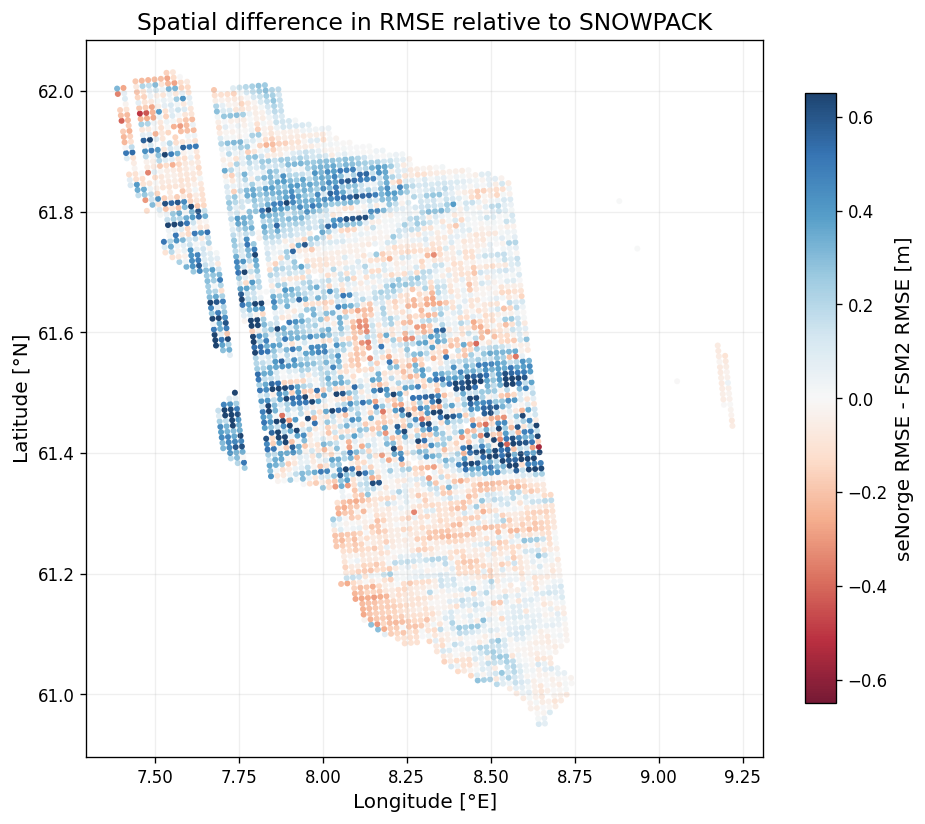

In [9]:
sp_ref = sp_ref.copy()
sp_ref["rmse_diff_senorge_minus_fsm2"] = sp_ref["rmse_senorge"] - sp_ref["rmse_fsm"]
vmax = float(np.nanpercentile(np.abs(sp_ref["rmse_diff_senorge_minus_fsm2"]), 98))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(8.0, 7.0))
sc = ax.scatter(
    sp_ref["lon"],
    sp_ref["lat"],
    c=sp_ref["rmse_diff_senorge_minus_fsm2"],
    s=13,
    cmap="RdBu",
    norm=norm,
    edgecolor="none",
    alpha=0.9,
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("seNorge RMSE - FSM2 RMSE [m]")
ax.set_title("Spatial difference in RMSE relative to SNOWPACK")
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.grid(True, alpha=0.20)
fig.tight_layout()
save_figure(fig, "10_rmse_difference_map_senorge_minus_fsm2")
plt.show()

## 8. Best-performing model map against observations

Saved: figures_thesis/11_best_model_map_observations.png
Saved: figures_thesis/11_best_model_map_observations.pdf


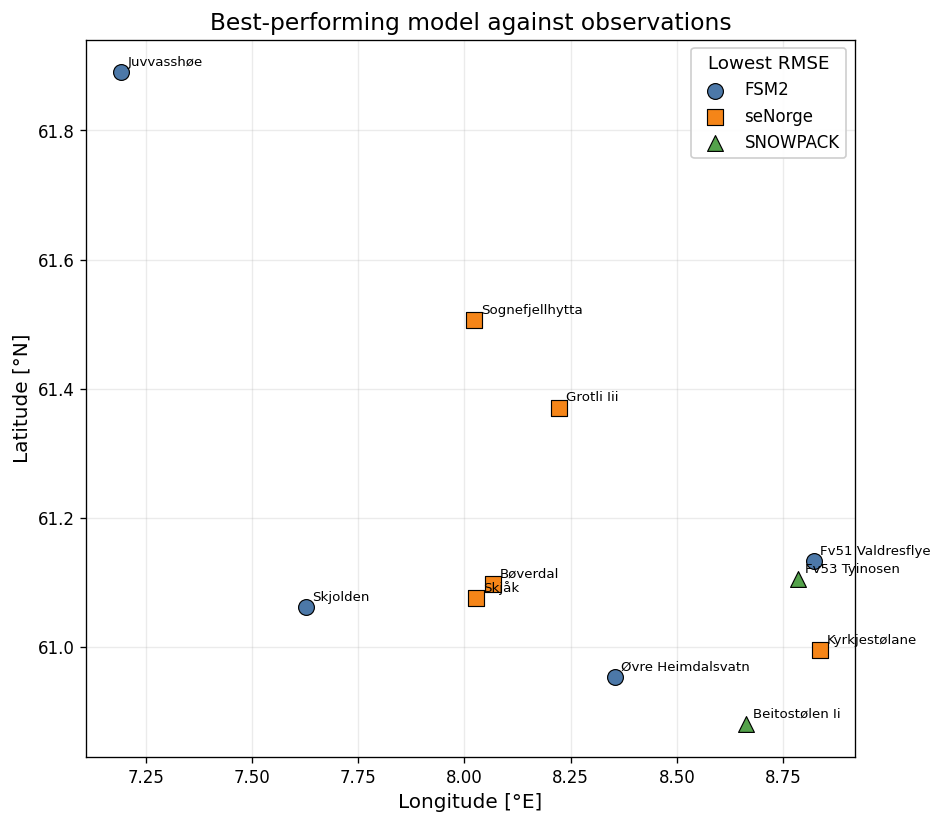

,Station,best_model,FSM2_RMSE,seNorge_RMSE,SNOWPACK_RMSE
0,Øvre Heimdalsvatn,FSM2,0.202290,0.234038,0.742371
1,Fv51 Valdresflye,FSM2,0.593570,0.598346,0.601916
2,Juvvasshøe,FSM2,0.488907,0.521931,2.490752
10,Skjolden,FSM2,0.211526,0.300543,0.539649
6,Beitostølen Ii,SNOWPACK,0.246073,0.317978,0.150896
8,Fv53 Tyinosen,SNOWPACK,0.323741,0.282366,0.238844
3,Bøverdal,seNorge,0.876578,0.386686,0.790029
4,Skjåk,seNorge,0.933699,0.560551,0.804264
5,Grotli Iii,seNorge,1.133249,0.799574,1.003969
7,Filefjell - Kyrkjestølane,seNorge,0.200258,0.116564,0.194859


In [10]:
obs_val = obs_val.copy()
rmse_cols = ["FSM2_RMSE", "seNorge_RMSE", "SNOWPACK_RMSE"]
obs_val["best_model"] = obs_val[rmse_cols].idxmin(axis=1).str.replace("_RMSE", "", regex=False)

fig, ax = plt.subplots(figsize=(8.0, 7.0))
for model in ["FSM2", "seNorge", "SNOWPACK"]:
    subset = obs_val[obs_val["best_model"] == model]
    ax.scatter(
        subset["lon"],
        subset["lat"],
        s=90,
        color=MODEL_COLORS[model],
        marker=MODEL_MARKERS[model],
        edgecolor="black",
        linewidth=0.7,
        label=model,
        zorder=3,
    )

for _, row in obs_val.iterrows():
    label = row["Station"].replace("Filefjell - ", "")
    ax.annotate(label, (row["lon"], row["lat"]), xytext=(4, 4), textcoords="offset points", fontsize=8)

ax.set_title("Best-performing model against observations")
ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.grid(True, alpha=0.25)
ax.legend(title="Lowest RMSE", loc="best", framealpha=0.95)
fig.tight_layout()
save_figure(fig, "11_best_model_map_observations")
plt.show()

obs_val[["Station", "best_model", "FSM2_RMSE", "seNorge_RMSE", "SNOWPACK_RMSE"]].sort_values("best_model")

## 9. Time series examples

Saved: figures_thesis/12_timeseries_examples_observations.png
Saved: figures_thesis/12_timeseries_examples_observations.pdf


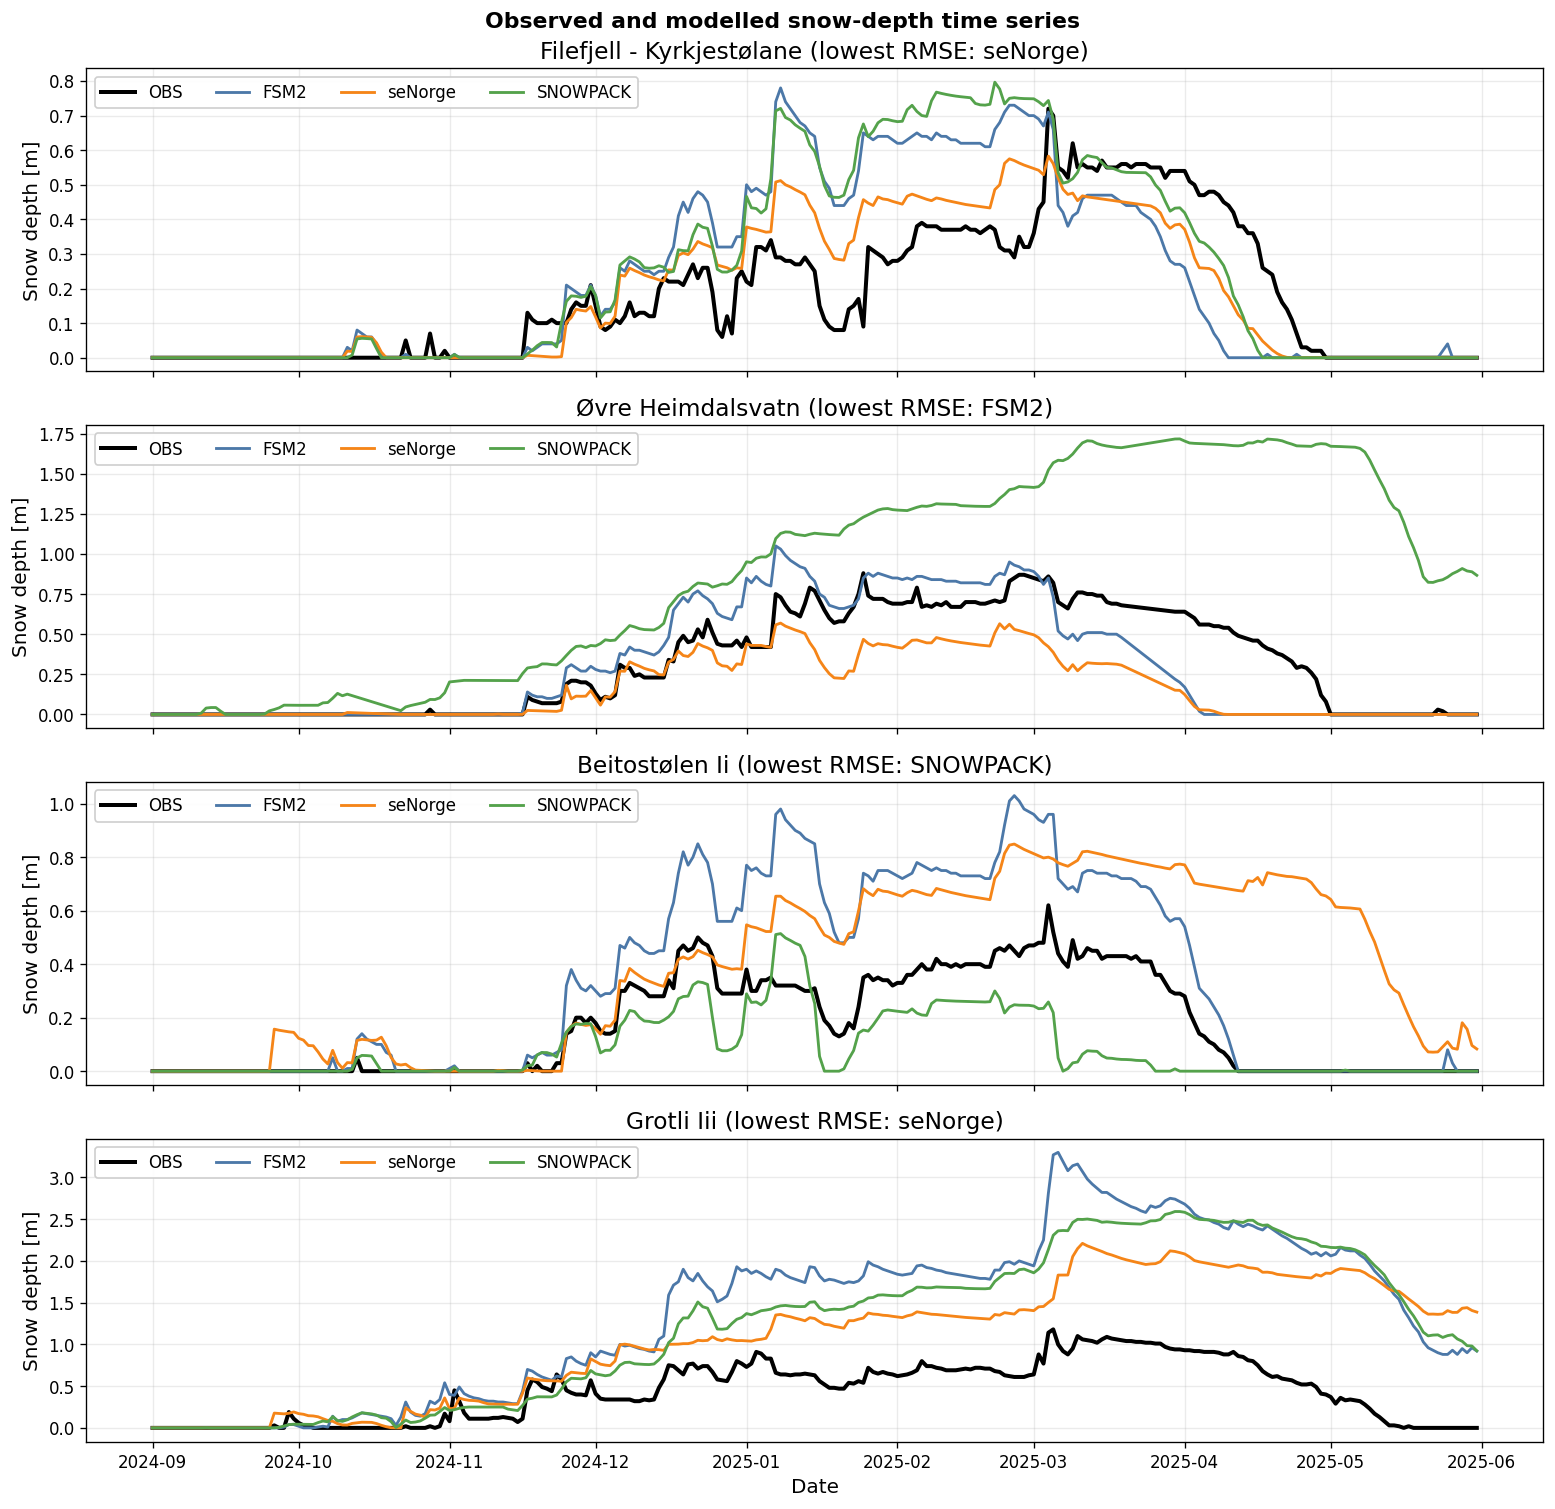

['Filefjell - Kyrkjestølane',
 'Øvre Heimdalsvatn',
 'Beitostølen Ii',
 'Grotli Iii']

In [11]:
example_stations = []
for model in ["seNorge", "FSM2", "SNOWPACK"]:
    subset = obs_val[obs_val["best_model"] == model]
    if not subset.empty:
        rmse_col = f"{model}_RMSE" if model != "seNorge" else "seNorge_RMSE"
        example_stations.append(subset.sort_values(rmse_col).iloc[0]["Station"])

# Add one high-error station based on the largest minimum RMSE across models.
obs_val["min_rmse"] = obs_val[rmse_cols].min(axis=1)
high_error_station = obs_val.sort_values("min_rmse", ascending=False).iloc[0]["Station"]
example_stations.append(high_error_station)
example_stations = list(dict.fromkeys(example_stations))[:4]

fig, axes = plt.subplots(len(example_stations), 1, figsize=(13, 3.2 * len(example_stations)), sharex=True)
if len(example_stations) == 1:
    axes = [axes]

for ax, station in zip(axes, example_stations):
    ts = obs_ts[obs_ts["Station"] == station].sort_values("time")
    ax.plot(ts["time"], ts["OBS"], color="black", linewidth=2.4, label="OBS")
    ax.plot(ts["time"], ts["FSM2"], color=MODEL_COLORS["FSM2"], linewidth=1.7, label="FSM2")
    ax.plot(ts["time"], ts["seNorge"], color=MODEL_COLORS["seNorge"], linewidth=1.7, label="seNorge")
    ax.plot(ts["time"], ts["SNOWPACK"], color=MODEL_COLORS["SNOWPACK"], linewidth=1.7, label="SNOWPACK")
    best = obs_val.loc[obs_val["Station"] == station, "best_model"].iloc[0]
    ax.set_title(f"{station} (lowest RMSE: {best})")
    ax.set_ylabel("Snow depth [m]")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", ncol=4, framealpha=0.95)

axes[-1].set_xlabel("Date")
fig.suptitle("Observed and modelled snow-depth time series", fontweight="bold")
fig.tight_layout()
save_figure(fig, "12_timeseries_examples_observations")
plt.show()

example_stations

## Output files

In [12]:
sorted([p.name for p in FIG_DIR.glob("*")])

['01_modelled_vs_observed_scatter.pdf',
 '01_modelled_vs_observed_scatter.png',
 '02_mean_rmse_observations.pdf',
 '02_mean_rmse_observations.png',
 '03_mean_bias_observations.pdf',
 '03_mean_bias_observations.png',
 '04_mean_correlation_observations.pdf',
 '04_mean_correlation_observations.png',
 '05_rmse_versus_elevation.pdf',
 '05_rmse_versus_elevation.png',
 '06_bias_versus_elevation.pdf',
 '06_bias_versus_elevation.png',
 '07_seasonal_rmse_comparison.pdf',
 '07_seasonal_rmse_comparison.png',
 '08_difference_map_midwinter_mean.pdf',
 '08_difference_map_midwinter_mean.png',
 '09_difference_map_melt_mean.pdf',
 '09_difference_map_melt_mean.png',
 '10_rmse_difference_map_senorge_minus_fsm2.pdf',
 '10_rmse_difference_map_senorge_minus_fsm2.png',
 '11_best_model_map_observations.pdf',
 '11_best_model_map_observations.png',
 '12_timeseries_examples_observations.pdf',
 '12_timeseries_examples_observations.png']